In [2]:
import pandas as pd
import numpy as np

In [44]:
df = pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')

In [46]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


In [48]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [50]:
df['oldpeak'].fillna(df['oldpeak'].mean(), inplace=True)


C:\Users\adity\AppData\Local\Temp\ipykernel_8728\3065579019.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].mean(), inplace=True)


In [52]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [54]:
data = df.copy()

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Apply one-hot encoding to categorical columns (automatically handles all categorical variables)
data_encoded = pd.get_dummies(data)

# Check the encoded data (optional)
print(data_encoded.head())

imputer = SimpleImputer(strategy='mean')
X = data_encoded.drop('num', axis=1)  # Replace with the actual target column
X_imputed = imputer.fit_transform(X)


y = data_encoded['num']  # Replace with the actual target column

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree model
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


   age  trestbps  chol    fbs  thalch  oldpeak  num  sex_Female  sex_Male  \
0   63       145   233   True     150      2.3    0       False      True   
1   41       135   203  False     132      0.0    0       False      True   
2   57       140   192  False     148      0.4    0       False      True   
3   52       118   186  False     190      0.0    0       False      True   
4   57       110   201  False     126      1.5    0       False      True   

   cp_asymptomatic  ...  exang_False  exang_True  exang_FALSE  exang_TURE  \
0            False  ...         True       False        False       False   
1            False  ...         True       False        False       False   
2             True  ...         True       False        False       False   
3            False  ...         True       False        False       False   
4             True  ...        False        True        False       False   

   slope_downsloping  slope_flat  slope_upsloping  thal_fixed defect  \
0 

In [58]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best parameters and evaluation
print("Best parameters:", grid_search.best_params_)
y_pred_optimized = grid_search.predict(X_test)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_optimized))


Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 20}
Optimized Accuracy: 0.5604395604395604


In [60]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Evaluate the model
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification report (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
print("Feature Importance:")
for feature, importance in zip(X.columns, clf.feature_importances_):
    print(f"{feature}: {importance:.4f}")


Accuracy: 51.65%
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73        89
           1       0.37      0.42      0.39        48
           2       0.32      0.27      0.29        22
           3       0.13      0.12      0.12        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.31      0.31      0.31       182
weighted avg       0.50      0.52      0.51       182

Confusion Matrix:
[[66 15  5  3  0]
 [17 20  4  5  2]
 [ 3 11  6  2  0]
 [ 3  8  3  2  1]
 [ 2  0  1  3  0]]
Feature Importance:
age: 0.1453
trestbps: 0.1072
chol: 0.1703
fbs: 0.0173
thalch: 0.1312
oldpeak: 0.1104
sex_Female: 0.0046
sex_Male: 0.0090
cp_asymptomatic: 0.1145
cp_atypical angina: 0.0080
cp_non-anginal: 0.0000
cp_typical angina: 0.0102
restecg_lv hypertrophy: 0.0065
restecg_normal: 0.0282
restecg_st-t abnormality: 0.0117
exang_False: 0.0318
exang_True: 0.

Unique class labels in y_train: [0 1 3 2 4]


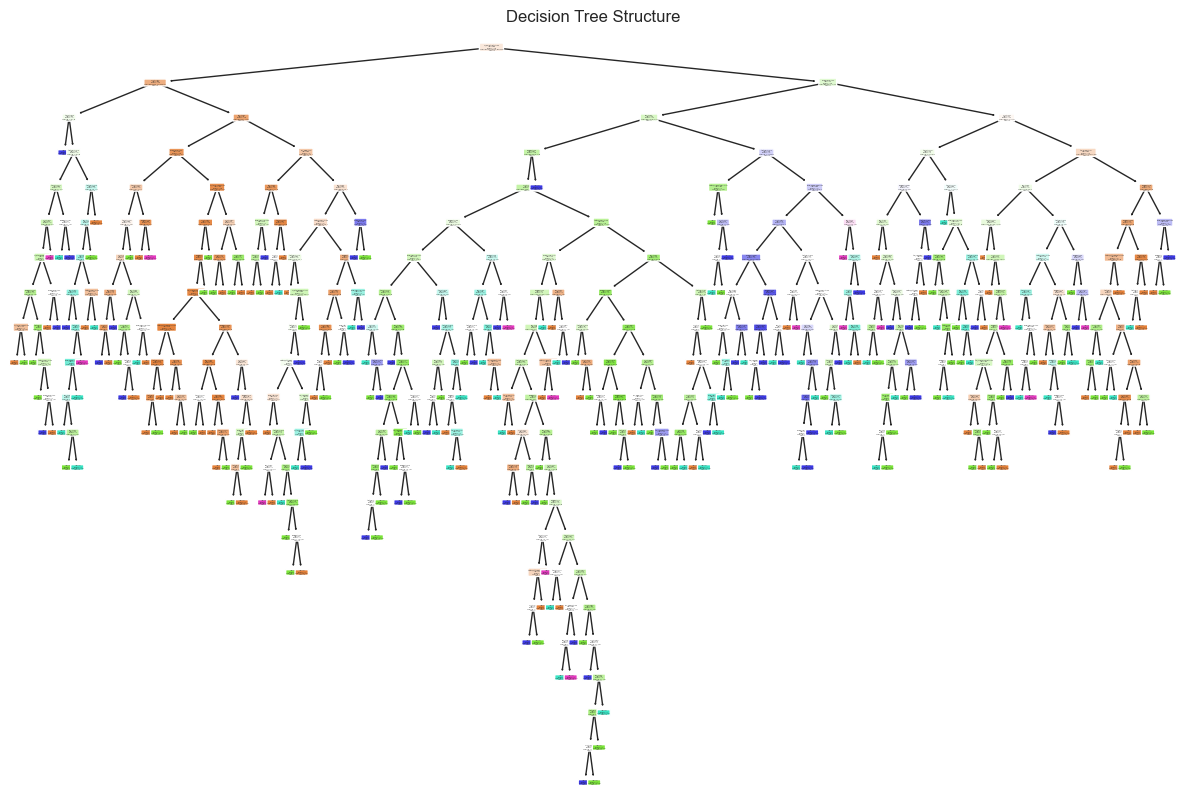

In [62]:
# Check the unique class labels in the target variable
print("Unique class labels in y_train:", y_train.unique())

# Use the actual class names based on the unique labels
plt.figure(figsize=(15, 10))

# Update class_names based on the unique labels in the data
# Use y_train.unique() to create the class_names list dynamically
class_labels = [str(int(label)) for label in y_train.unique()]  # Convert to string if needed

plot_tree(clf, filled=True, feature_names=X.columns, class_names=class_labels, rounded=True)
plt.title("Decision Tree Structure")
plt.show()


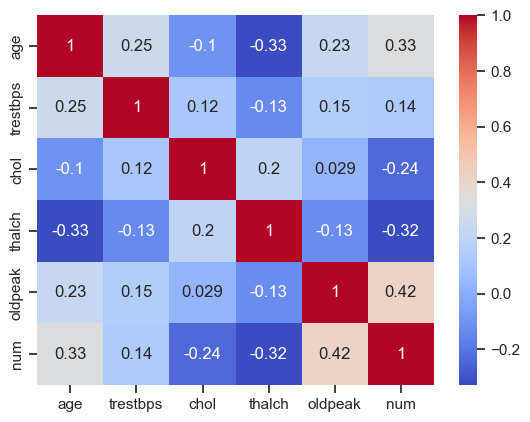

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from the DataFrame
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation matrix on the numeric data
correlation_matrix = numeric_data.corr()

# Plot the heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()


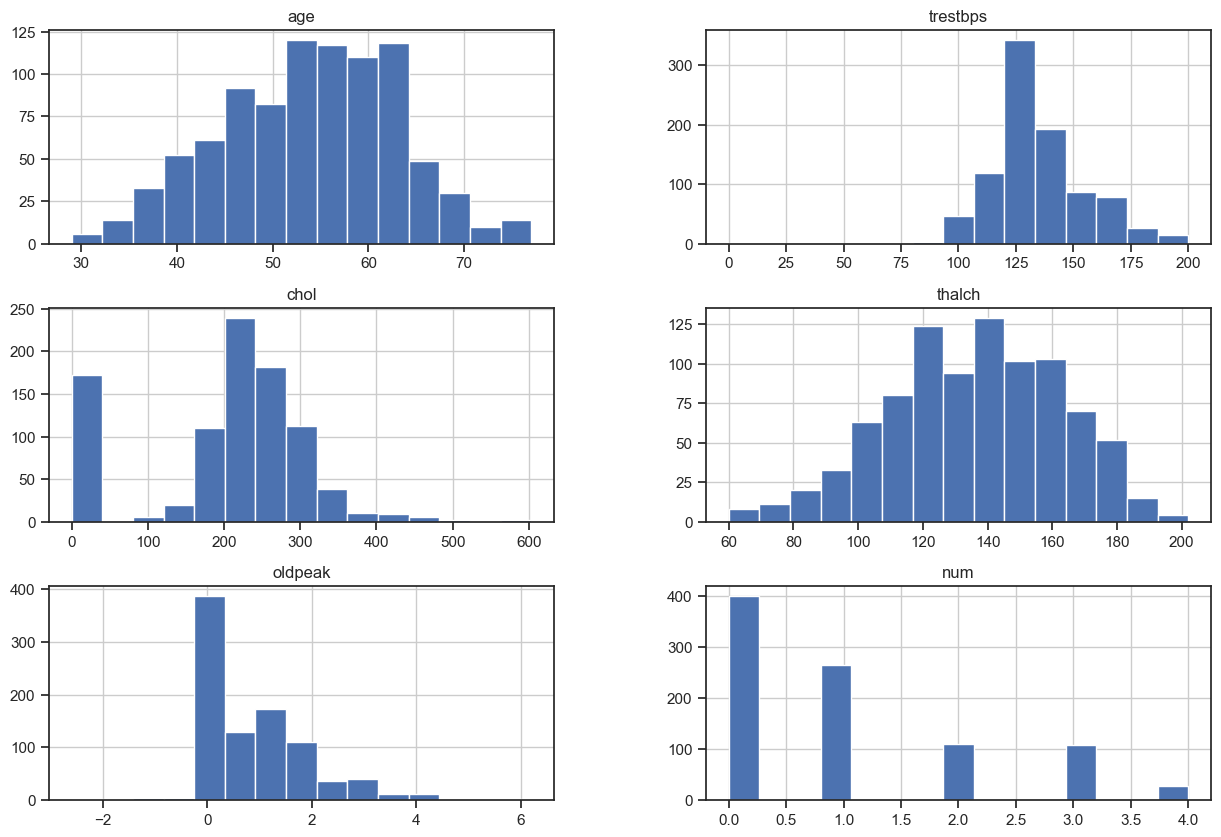

In [71]:
data.hist(bins=15, figsize=(15,10))
plt.show()

<Figure size 1000x1000 with 0 Axes>

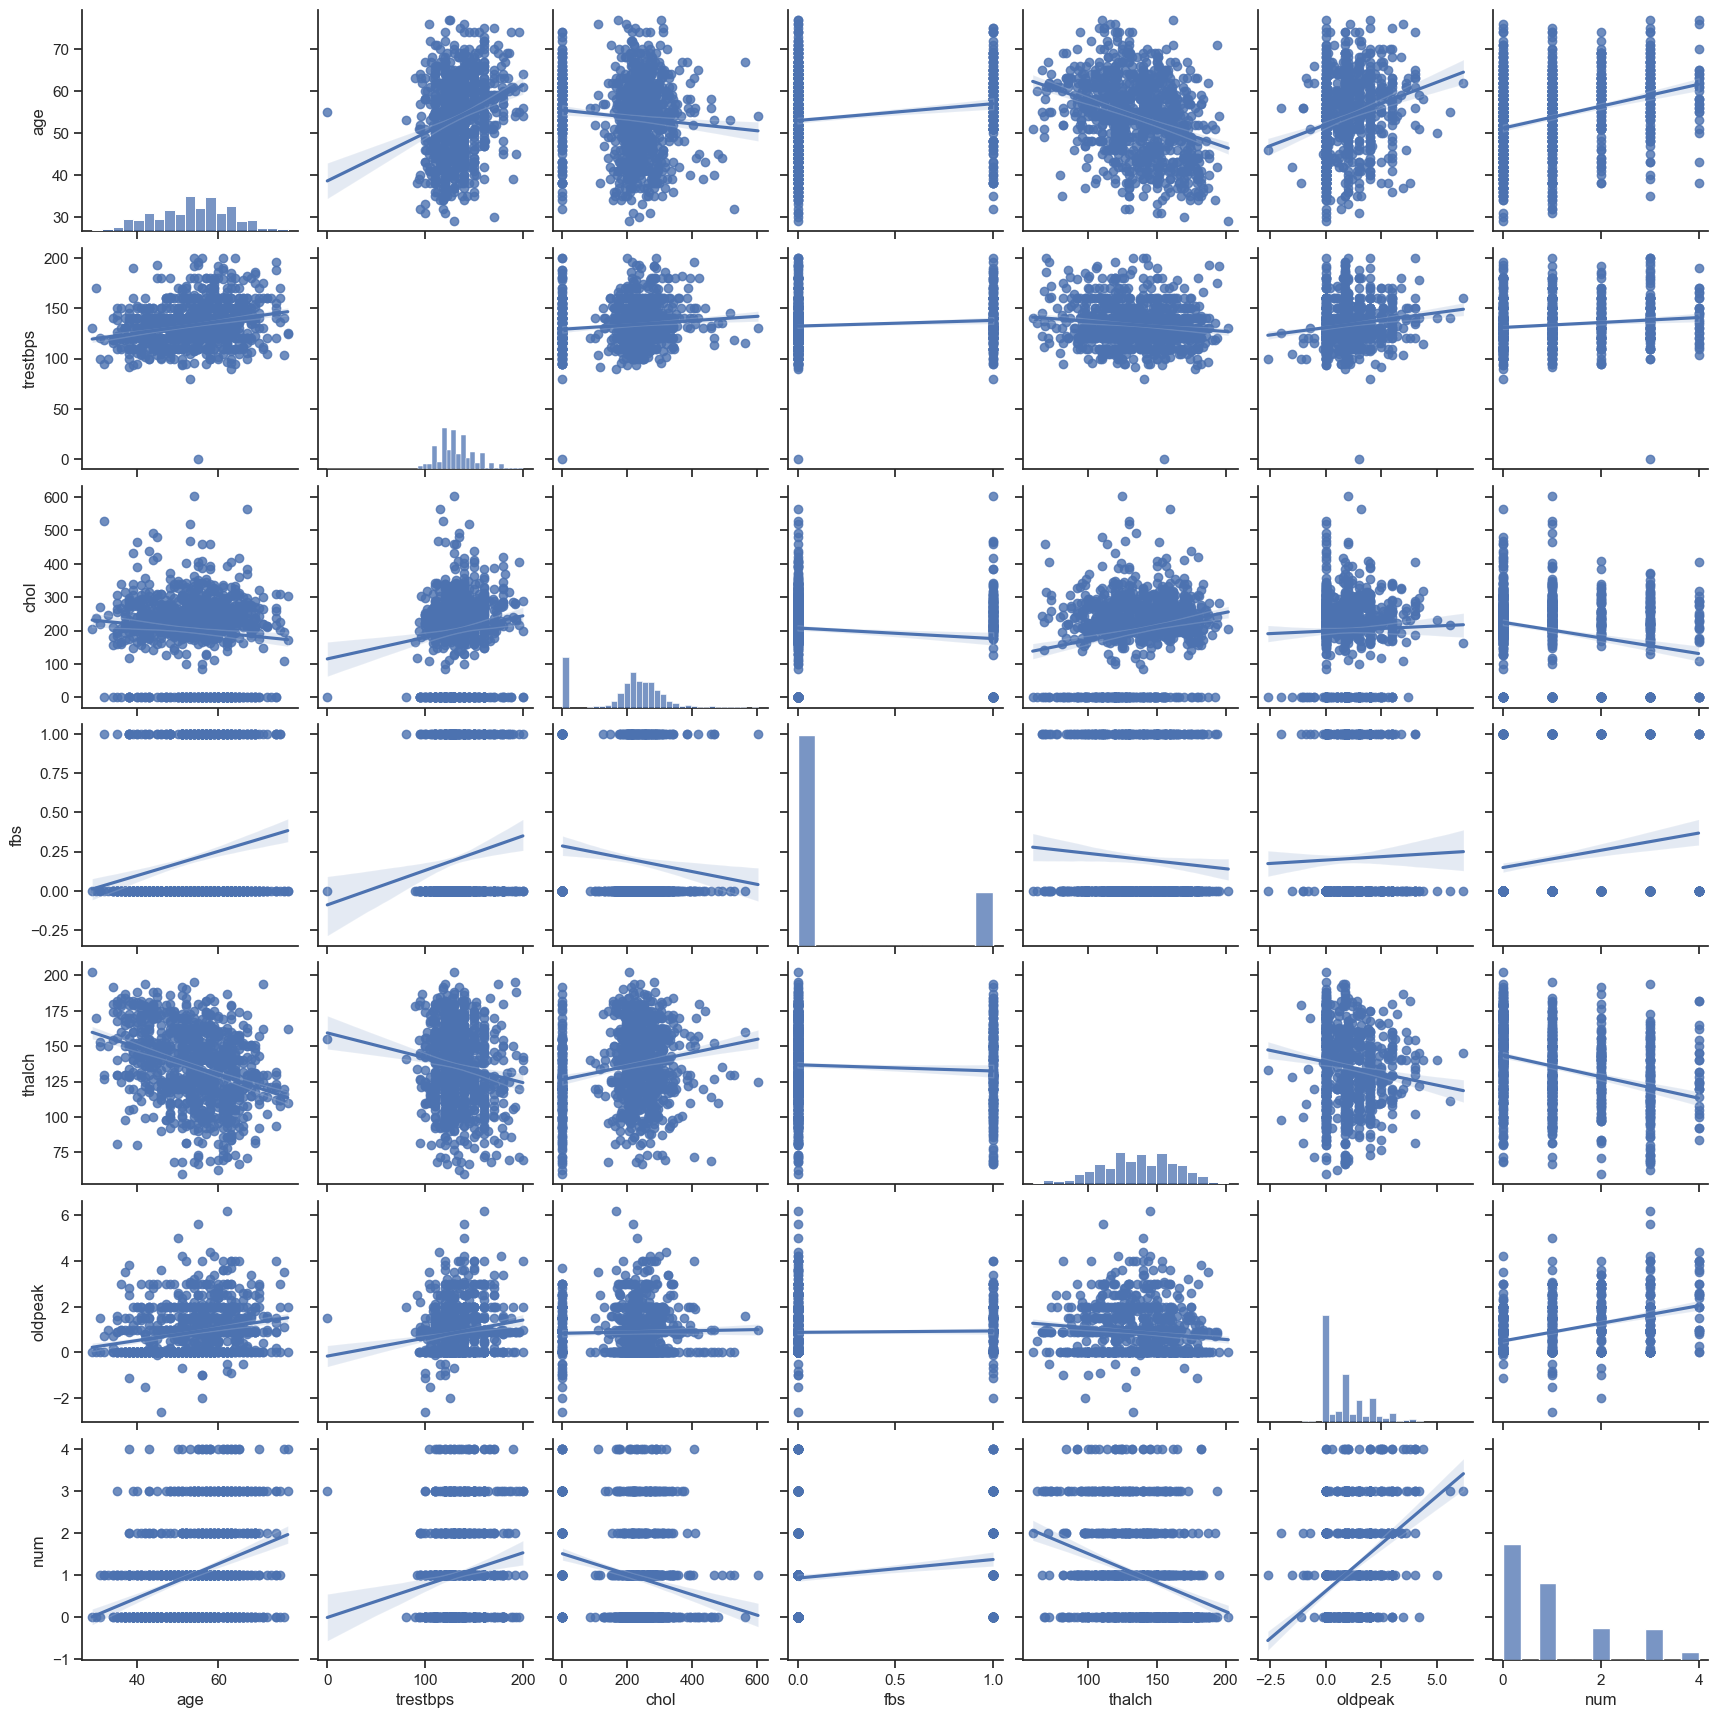

In [73]:
plt.figure(figsize=(10, 10))
sns.set(style="ticks", color_codes=True)
sns.pairplot(data, kind="reg")
plt.show()